# Complete Data Preprocessing & Feature Engineering Plan

## Objective

This notebook extends the existing Resume Intelligence EDA with the preprocessing,
feature engineering, feature selection, feature extraction, scaling, encoding,
dimensionality reduction, and validation steps required for the assignment.

The workflow uses the publicly available `UpdatedResumeDataSet.csv` dataset and
does not depend on proprietary candidate data.


## 1. Why Data Preprocessing Is Important

Raw resume data can contain missing values, duplicates, empty records, inconsistent
text, unusual document lengths, and irrelevant tokens. These issues can affect
NLP representations and produce misleading model results.

The preprocessing strategy follows:

**Data Understanding → Data Quality → Cleaning → EDA → Feature Engineering →
Feature Extraction → Feature Selection → Scaling/Encoding → Dimensionality
Reduction → Validation**

Each step is justified by the properties of the data rather than applying
transformations automatically.


## 2. Python Libraries

- **pandas:** data loading, inspection, cleaning, grouping and transformation.
- **NumPy:** numerical calculations and array operations.
- **matplotlib:** basic visualization.
- **seaborn:** statistical visualization.
- **scikit-learn:** train/test splitting, TF-IDF, scaling, encoding, feature
  selection, cosine similarity and dimensionality reduction.
- **re:** controlled text normalization and skill matching.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="whitegrid")

DATA_PATH = "UpdatedResumeDataSet.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Dataset loaded successfully.
Shape: (962, 2)
Columns: ['Category', 'Resume']


## 3. Data Understanding and Quality Assessment

Before changing the dataset, inspect its structure. This establishes a reproducible
baseline and provides evidence for later preprocessing decisions.


In [36]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)


Shape: (962, 2)

Columns:
['Category', 'Resume']

Data types:
Category    object
Resume      object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB

Descriptive statistics:


,count,unique,top,freq
Category,962,25,Java Developer,84
Resume,962,166,"Technical Skills Web Technologies: Angular JS,...",18


In [37]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

print("\nUnique values:")
print(df.nunique())


Missing values:
Category    0
Resume      0
dtype: int64

Total duplicate rows:
796

Unique values:
Category     25
Resume      166
dtype: int64


## 4. Missing Values

For text fields, missing values are handled explicitly. An empty string prevents
`NaN` values from propagating through string operations.

Completely empty resume records are separately identified because they do not
provide meaningful NLP information.


In [38]:
print("Missing values BEFORE:")
print(df.isnull().sum())

df["Resume"] = df["Resume"].fillna("")

print("\nMissing values AFTER filling Resume:")
print(df.isnull().sum())

empty_resume_mask = df["Resume"].str.strip().eq("")
print("\nEmpty resume records:", empty_resume_mask.sum())


Missing values BEFORE:
Category    0
Resume      0
dtype: int64

Missing values AFTER filling Resume:
Category    0
Resume      0
dtype: int64

Empty resume records: 0


## 5. Duplicate Records

Duplicate records can make a model appear more accurate than it really is,
especially if identical records are split between training and testing data.
Duplicates are therefore removed before the train/test split.


In [39]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicates_after = df.duplicated().sum()

print("Duplicates before:", duplicates_before)
print("Duplicates after:", duplicates_after)
print("Rows remaining:", len(df))


Duplicates before: 796
Duplicates after: 0
Rows remaining: 166


## 6. Text Cleaning

Resume text contains useful technical terms, so cleaning should be conservative.
The cleaned text is stored separately so the original resume text remains available.


In [40]:
def clean_resume_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_resume"] = df["Resume"].apply(clean_resume_text)

print("Original:")
print(df["Resume"].iloc[0][:300])

print("\nCleaned:")
print(df["clean_resume"].iloc[0][:300])


Original:
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language pr

Cleaned:
skills * programming languages: python (pandas, numpy, scipy, scikit-learn, matplotlib), sql, java, javascript/jquery. * machine learning: regression, svm, naã¯ve bayes, knn, random forest, decision trees, boosting techniques, cluster analysis, word embedding, sentiment analysis, natural language pr


## 7. Feature Engineering

The following features describe resume structure:

- `word_count`
- `char_count`
- `sentence_count`
- `skill_count`

These features support EDA and can later contribute to a hybrid matching score.


In [41]:
df["char_count"] = df["clean_resume"].str.len()
df["word_count"] = df["clean_resume"].str.split().str.len()
df["sentence_count"] = df["Resume"].str.count(r"[.!?]")

print(df[[
    "char_count", "word_count", "sentence_count"
]].describe())


         char_count   word_count  sentence_count
count    166.000000   166.000000      166.000000
mean    2914.024096   424.771084       24.234940
std     2609.664646   380.604490       24.803206
min      124.000000    19.000000        0.000000
25%     1015.750000   161.250000        6.250000
50%     2302.000000   330.000000       19.000000
75%     3825.250000   571.500000       34.000000
max    14552.000000  2209.000000      187.000000


In [42]:
skills = [
    "python", "java", "javascript", "react", "node", "django", "fastapi",
    "sql", "mysql", "postgresql", "mongodb", "aws", "docker", "kubernetes",
    "tensorflow", "pytorch", "pandas", "numpy", "scikit-learn",
    "machine learning", "data science", "html", "css", "git"
]

def contains_skill(text, skill):
    pattern = r"(?<!\w)" + re.escape(skill.lower()) + r"(?!\w)"
    return bool(re.search(pattern, text.lower()))

def count_skills(text):
    return sum(contains_skill(text, skill) for skill in skills)

df["skill_count"] = df["clean_resume"].apply(count_skills)

print(df[[
    "Category", "word_count", "char_count",
    "sentence_count", "skill_count"
]].head())


       Category  word_count  char_count  sentence_count  skill_count
0  Data Science         670        4733              33           15
1  Data Science         163        1177               9            3
2  Data Science         265        1838               7            7
3  Data Science         993        6864              62            4
4  Data Science          69         427               0            3


## 8. Descriptive Statistics and Visualization

EDA is used to understand distributions, category balance, relationships between
features, and potential anomalies before modeling.


In [43]:
print("Category distribution:")
display(df["Category"].value_counts())

print("\nResume feature statistics:")
display(
    df[["word_count", "char_count", "sentence_count", "skill_count"]].describe()
)


Category distribution:


Category
Java Developer               13
Database                     11
Advocate                     10
HR                           10
Data Science                 10
Automation Testing            7
DevOps Engineer               7
Testing                       7
DotNet Developer              7
Hadoop                        7
SAP Developer                 6
Python Developer              6
Health and fitness            6
Civil Engineer                6
Arts                          6
Business Analyst              6
Sales                         5
Blockchain                    5
Mechanical Engineer           5
ETL Developer                 5
Electrical Engineering        5
Network Security Engineer     5
Web Designing                 4
Operations Manager            4
PMO                           3
Name: count, dtype: int64


Resume feature statistics:


,word_count,char_count,sentence_count,skill_count
count,166.000000,166.000000,166.000000,166.000000
mean,424.771084,2914.024096,24.234940,1.909639
std,380.604490,2609.664646,24.803206,2.655634
min,19.000000,124.000000,0.000000,0.000000
25%,161.250000,1015.750000,6.250000,0.000000
50%,330.000000,2302.000000,19.000000,1.000000
75%,571.500000,3825.250000,34.000000,3.000000
max,2209.000000,14552.000000,187.000000,15.000000


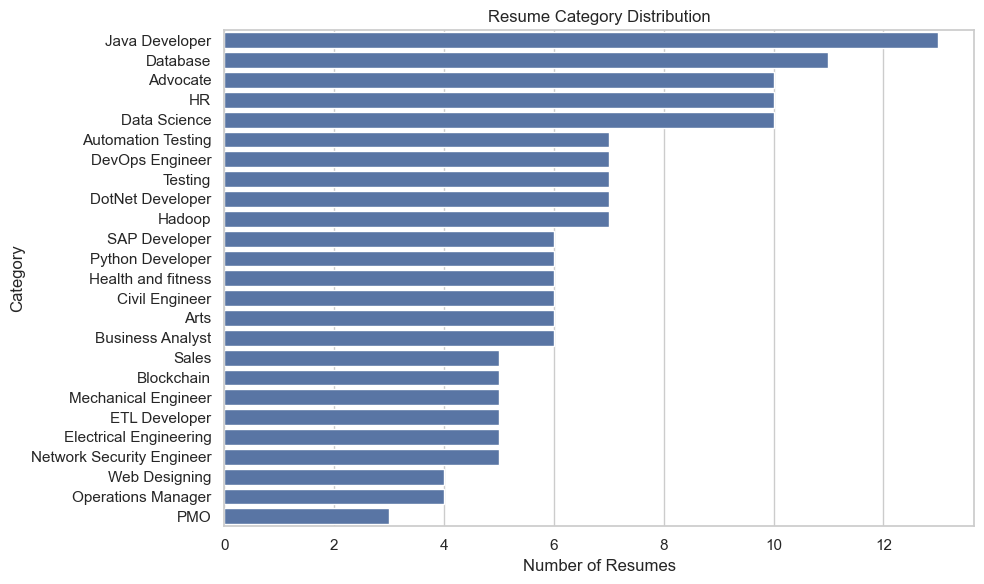

In [44]:
plt.figure(figsize=(10, 6))
order = df["Category"].value_counts().index

sns.countplot(
    data=df,
    y="Category",
    order=order
)

plt.title("Resume Category Distribution")
plt.xlabel("Number of Resumes")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


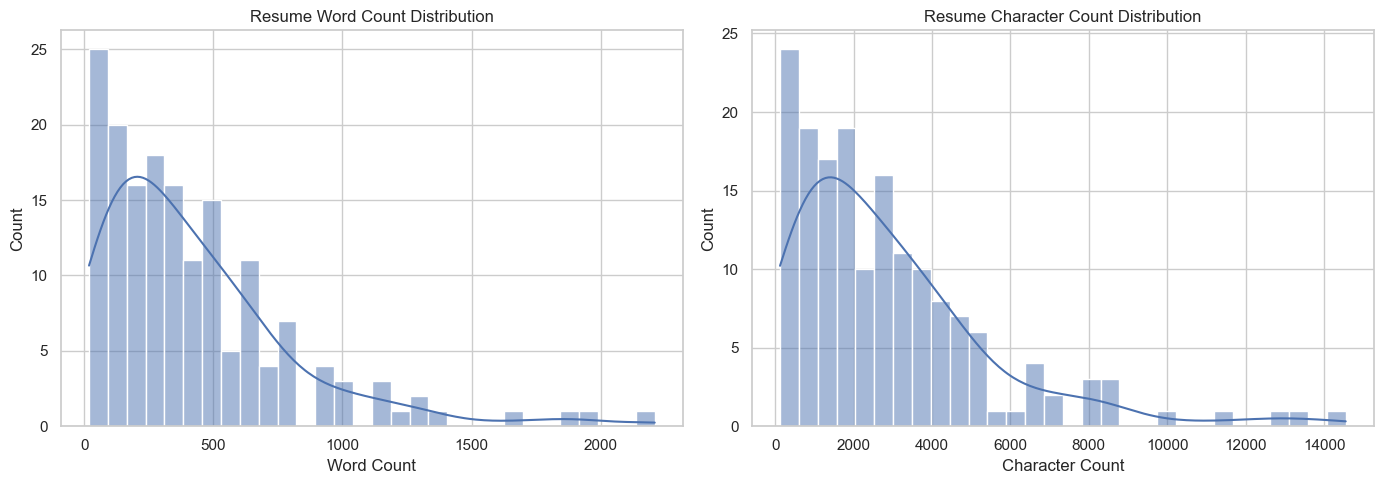

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["word_count"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Resume Word Count Distribution")
axes[0].set_xlabel("Word Count")

sns.histplot(df["char_count"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Resume Character Count Distribution")
axes[1].set_xlabel("Character Count")

plt.tight_layout()
plt.show()


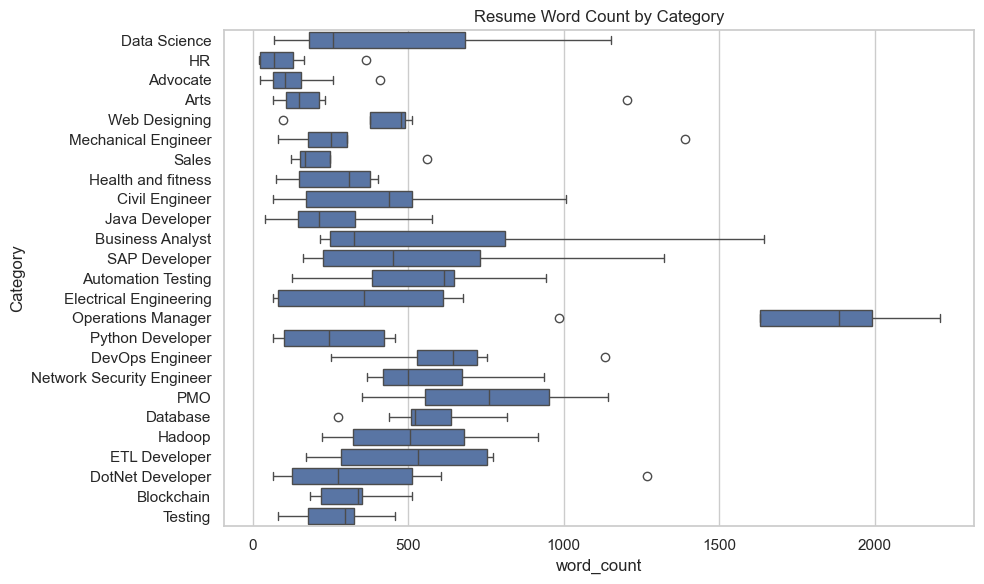

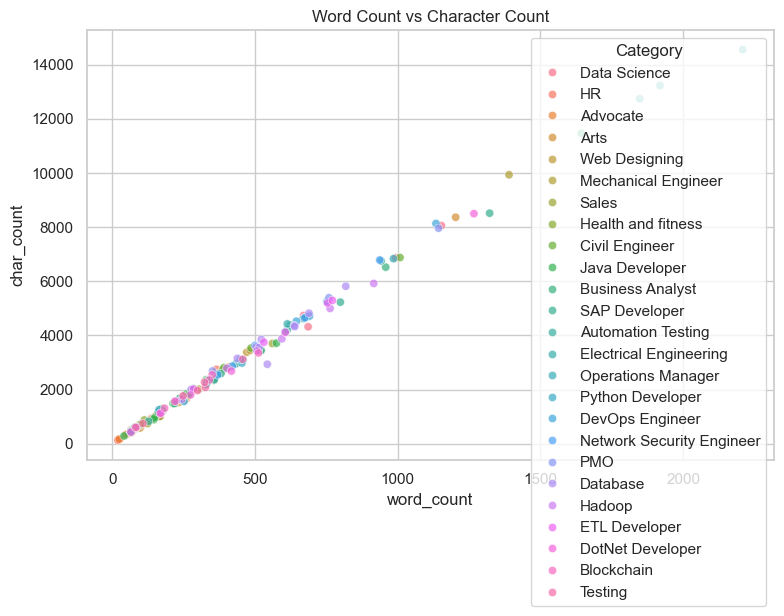

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="word_count", y="Category")
plt.title("Resume Word Count by Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="word_count",
    y="char_count",
    hue="Category",
    alpha=0.7
)
plt.title("Word Count vs Character Count")
plt.tight_layout()
plt.show()


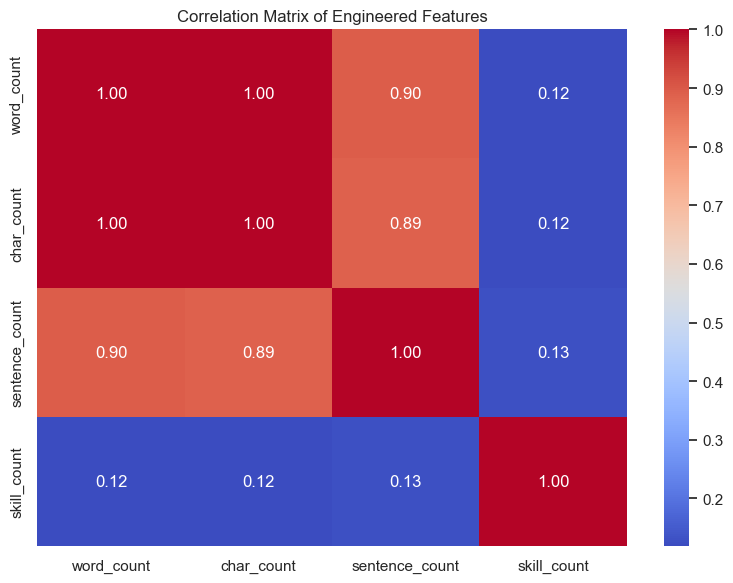

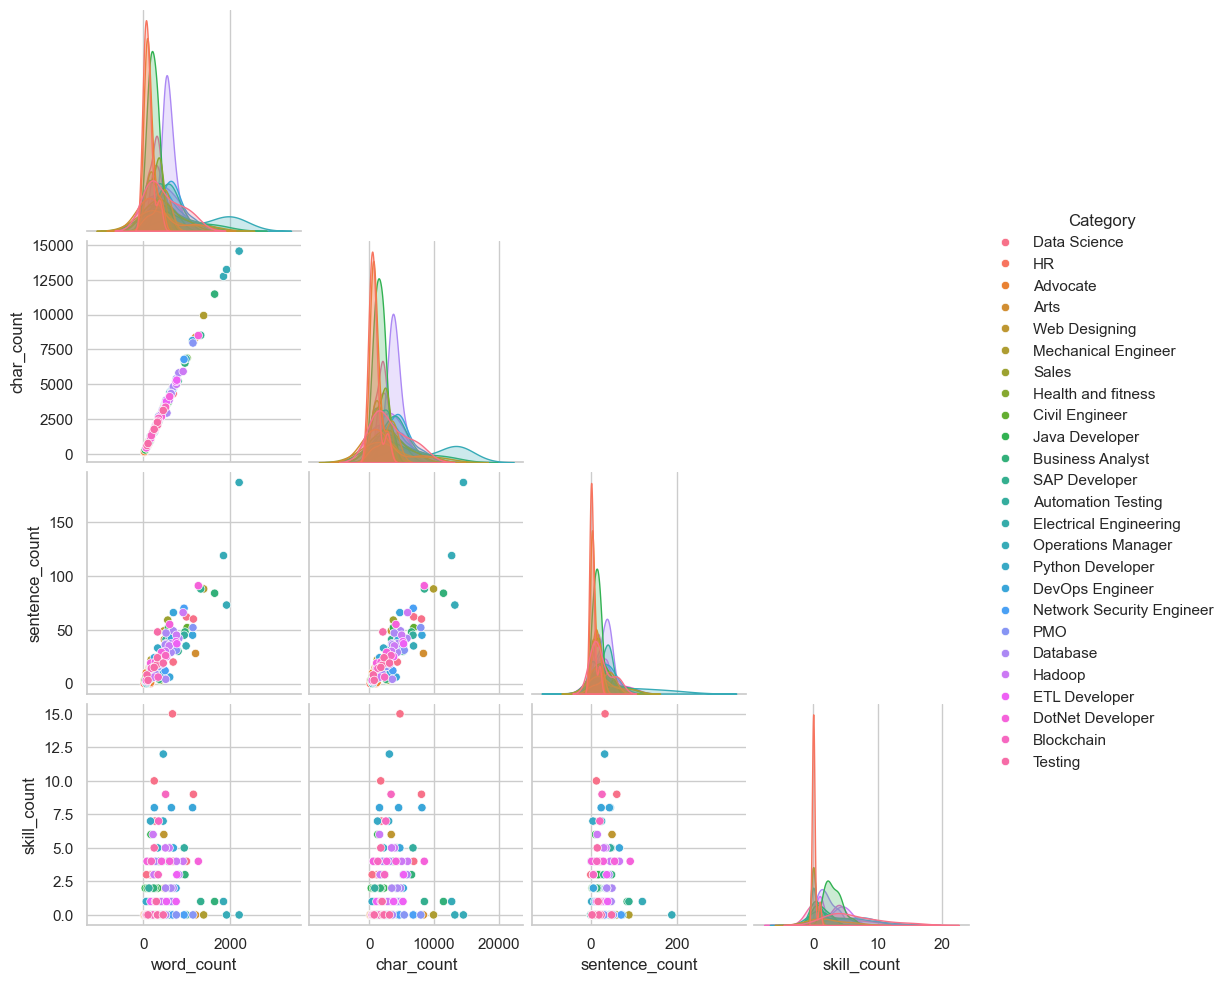

In [47]:
numeric_cols = [
    "word_count", "char_count", "sentence_count", "skill_count"
]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Matrix of Engineered Features")
plt.tight_layout()
plt.show()

sns.pairplot(
    df[numeric_cols + ["Category"]],
    hue="Category",
    corner=True
)
plt.show()


## 9. Outlier Analysis

A statistical outlier is not automatically an invalid resume. A very long resume
may be legitimate. Therefore, the IQR method identifies records for inspection
rather than automatically deleting them.


In [48]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (
    (df["word_count"] < lower_bound) |
    (df["word_count"] > upper_bound)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of statistical outliers:", outlier_mask.sum())

display(
    df.loc[outlier_mask, ["Category", "word_count", "char_count"]].head(10)
)


Q1: 161.25
Q3: 571.5
IQR: 410.25
Lower bound: -454.125
Upper bound: 1186.875
Number of statistical outliers: 8


,Category,word_count,char_count
32,Arts,1203,8362
40,Mechanical Engineer,1390,9930
78,Business Analyst,1643,11465
82,SAP Developer,1322,8512
99,Operations Manager,1848,12737
101,Operations Manager,1919,13228
102,Operations Manager,2209,14552
152,DotNet Developer,1267,8494


## 10. NumPy Numerical Analysis

NumPy complements pandas by providing numerical operations on arrays and columns.


In [49]:
word_values = df["word_count"].to_numpy()

print("NumPy mean:", np.mean(word_values))
print("NumPy median:", np.median(word_values))
print("NumPy standard deviation:", np.std(word_values))


NumPy mean: 424.7710843373494
NumPy median: 330.0
NumPy standard deviation: 379.456358914317


## 11. Train/Test Split and Leakage Prevention

Transformations that learn parameters from data should be fitted on the training
set only. This prevents information from the test set influencing the learned
representation.

The split is stratified by `Category` so category proportions are better preserved.


In [50]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Category"]
)

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining category proportions:")
print(train_df["Category"].value_counts(normalize=True))


Training rows: 132
Testing rows: 34

Training category proportions:
Category
Java Developer               0.075758
Database                     0.068182
HR                           0.060606
Data Science                 0.060606
Advocate                     0.060606
Automation Testing           0.045455
DevOps Engineer              0.045455
Python Developer             0.037879
Health and fitness           0.037879
Hadoop                       0.037879
Civil Engineer               0.037879
Business Analyst             0.037879
SAP Developer                0.037879
DotNet Developer             0.037879
Testing                      0.037879
Arts                         0.037879
Blockchain                   0.030303
Sales                        0.030303
ETL Developer                0.030303
Mechanical Engineer          0.030303
Network Security Engineer    0.030303
Electrical Engineering       0.030303
Web Designing                0.022727
Operations Manager           0.022727
PMO        

## 12. TF-IDF Feature Extraction

TF-IDF is used as the lexical baseline because it is interpretable, efficient, and
well suited to measuring vocabulary overlap between resumes and job descriptions.

The vectorizer is fitted only on training text.


In [51]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(train_df["clean_resume"])
X_test_tfidf = tfidf.transform(test_df["clean_resume"])

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

feature_names = tfidf.get_feature_names_out()

print("\nFirst 20 vocabulary terms:")
print(feature_names[:20])


Training TF-IDF shape: (132, 5000)
Testing TF-IDF shape: (34, 5000)

First 20 vocabulary terms:
['03' '06th' '07' '07 08' '08' '08 description' '10' '10 days' '100' '10g'
 '11' '11 years' '1180' '11g' '11g 12c' '12' '12 months'
 '12 monthscompany' '120' '12c']


In [52]:
sample_query = [
    "Python Django developer with PostgreSQL Docker machine learning experience"
]

query_vector = tfidf.transform(sample_query)

similarities = cosine_similarity(
    query_vector,
    X_train_tfidf
)

print("Similarity matrix shape:", similarities.shape)
print("Top 5 similarity scores:",
      np.sort(similarities[0])[-5:][::-1])


Similarity matrix shape: (1, 132)
Top 5 similarity scores: [0.29815994 0.22280448 0.20234831 0.17335194 0.16699829]


## 13. Feature Selection

Feature extraction creates TF-IDF features. Feature selection chooses a subset
of useful existing features.

Chi-square selection is demonstrated because the dataset has categorical resume
labels. The selected feature count should be validated experimentally.


In [53]:
k = min(1000, X_train_tfidf.shape[1])

selector = SelectKBest(
    score_func=chi2,
    k=k
)

X_train_selected = selector.fit_transform(
    X_train_tfidf,
    train_df["Category"]
)

X_test_selected = selector.transform(
    X_test_tfidf
)

print("Original training shape:", X_train_tfidf.shape)
print("Selected training shape:", X_train_selected.shape)
print("Original testing shape:", X_test_tfidf.shape)
print("Selected testing shape:", X_test_selected.shape)


Original training shape: (132, 5000)
Selected training shape: (132, 1000)
Original testing shape: (34, 5000)
Selected testing shape: (34, 1000)


## 14. Feature Scaling

Numerical engineered features can have different ranges. StandardScaler
standardizes them approximately to zero mean and unit variance, while MinMaxScaler
maps them into a bounded range.

The original columns are preserved.


In [54]:
numeric_features = [
    "word_count", "char_count", "sentence_count", "skill_count"
]

standard_scaler = StandardScaler()

train_numeric_scaled = standard_scaler.fit_transform(
    train_df[numeric_features]
)

test_numeric_scaled = standard_scaler.transform(
    test_df[numeric_features]
)

scaled_train_df = pd.DataFrame(
    train_numeric_scaled,
    columns=[f"{c}_scaled" for c in numeric_features],
    index=train_df.index
)

display(scaled_train_df.head())


,word_count_scaled,char_count_scaled,sentence_count_scaled,skill_count_scaled
53,-0.098705,-0.064524,-0.981670,-0.728336
130,0.598641,0.569183,0.258791,-0.346827
92,0.681330,0.687703,0.497341,-0.346827
155,-0.197932,-0.140744,-0.122889,1.942229
106,0.088724,0.031650,0.067951,1.942229


In [55]:
minmax_scaler = MinMaxScaler()

train_numeric_minmax = minmax_scaler.fit_transform(
    train_df[numeric_features]
)

test_numeric_minmax = minmax_scaler.transform(
    test_df[numeric_features]
)

minmax_train_df = pd.DataFrame(
    train_numeric_minmax,
    columns=[f"{c}_minmax" for c in numeric_features],
    index=train_df.index
)

display(minmax_train_df.head())


,word_count_minmax,char_count_minmax,sentence_count_minmax,skill_count_minmax
53,0.193158,0.199328,0.025210,0.000000
130,0.326316,0.320513,0.243697,0.066667
92,0.342105,0.343178,0.285714,0.066667
155,0.174211,0.184753,0.176471,0.466667
106,0.228947,0.217720,0.210084,0.466667


## 15. One-Hot Encoding

The current resume dataset is primarily text-based and does not contain a clean
structured categorical predictor such as Education or Location. Therefore, a small
synthetic example demonstrates the technique without inventing fields in the real
dataset.

In a future structured version, OneHotEncoder can be applied to education level,
location, employment type, or experience level.


In [56]:
demo_categories = pd.DataFrame({
    "Education": ["B.Com", "B.Tech", "MCA", "B.Com", "MBA"]
})

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

encoded_education = encoder.fit_transform(
    demo_categories[["Education"]]
)

encoded_education_df = pd.DataFrame(
    encoded_education,
    columns=encoder.get_feature_names_out(["Education"])
)

print("Original categorical data:")
display(demo_categories)

print("Encoded data:")
display(encoded_education_df)


Original categorical data:


,Education
0,B.Com
1,B.Tech
2,MCA
3,B.Com
4,MBA


Encoded data:


,Education_B.Com,Education_B.Tech,Education_MBA,Education_MCA
0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


## 16. Dimensionality Reduction with Truncated SVD

TF-IDF can generate thousands of sparse dimensions. Truncated SVD can compress
this representation into fewer components.

The number of components should be selected using explained-variance evidence and
downstream model performance rather than chosen arbitrarily.


In [57]:
n_components = min(100, X_train_tfidf.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=42
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

explained_variance = svd.explained_variance_ratio_.sum()

print("Original training shape:", X_train_tfidf.shape)
print("Reduced training shape:", X_train_svd.shape)
print("Original testing shape:", X_test_tfidf.shape)
print("Reduced testing shape:", X_test_svd.shape)
print("Explained variance ratio sum:", explained_variance)


Original training shape: (132, 5000)
Reduced training shape: (132, 100)
Original testing shape: (34, 5000)
Reduced testing shape: (34, 100)
Explained variance ratio sum: 0.8696132262838315


In [58]:
for components in [25, 50, 100]:
    if components < X_train_tfidf.shape[1]:
        temp_svd = TruncatedSVD(
            n_components=components,
            random_state=42
        )
        temp_svd.fit(X_train_tfidf)
        print(
            f"{components} components -> "
            f"{temp_svd.explained_variance_ratio_.sum():.4f} "
            "explained variance"
        )


25 components -> 0.3691 explained variance
50 components -> 0.5696 explained variance
100 components -> 0.8696 explained variance


## 17. Processing-Step Validation

Each transformation should be tested independently. Record the actual outputs
from this notebook as evidence in the report.

### Evidence to record

- Dataset shape before/after cleaning
- Missing values before/after
- Duplicate count before/after
- Empty resume count
- Outlier count and IQR bounds
- Engineered feature statistics
- TF-IDF matrix dimensions
- Example cosine similarity scores
- Number of selected features
- Scaling output/statistics
- One-hot encoded dimensions
- SVD dimensions and explained variance
- Train/test split sizes


In [59]:
validation_summary = {
    "rows_after_cleaning": len(df),
    "missing_values_total": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "empty_resumes": int(df["clean_resume"].str.strip().eq("").sum()),
    "word_count_outliers": int(outlier_mask.sum()),
    "tfidf_train_rows": X_train_tfidf.shape[0],
    "tfidf_train_features": X_train_tfidf.shape[1],
    "selected_features": X_train_selected.shape[1],
    "svd_components": X_train_svd.shape[1],
    "svd_explained_variance": float(explained_variance)
}

for key, value in validation_summary.items():
    print(f"{key}: {value}")


rows_after_cleaning: 166
missing_values_total: 0
duplicate_rows: 0
empty_resumes: 0
word_count_outliers: 8
tfidf_train_rows: 132
tfidf_train_features: 5000
selected_features: 1000
svd_components: 100
svd_explained_variance: 0.8696132262838315
